# DAPRO projection accuracy and budget control

This notebook compares the projected continuation policy with the full-calibration oracle policy. It separates projection-induced expected-budget error from Monte Carlo sampling noise in the realized budget.

In [5]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.safety_evaluation.dapro_projection_evaluation_utils import get_dapro_projection_experiment_name

# DATASET_NAME = "dataset_red_team"
# DATASET_SETUP = "attack_default_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_llm-judge_qwen25_14b_instruct"


DATASET_NAME = "dataset_toxicity"
DATASET_SETUP = "attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify"

BUDGET_PER_SAMPLE = 20.0
CAL_SIZE = 3000
TAU_PRIOR = 0.56
M_UPPER_BOUND = 200.0

experiment_name = get_dapro_projection_experiment_name(
    DATASET_NAME, DATASET_SETUP, BUDGET_PER_SAMPLE, CAL_SIZE, TAU_PRIOR, M_UPPER_BOUND
)
results_path = PROJECT_ROOT / "results" / "merged_dapro_projection_evaluation" / experiment_name / "all_df.csv"
figures_dir = PROJECT_ROOT / "notebooks" / "figures" / "dapro_projection" / experiment_name
figures_dir.mkdir(parents=True, exist_ok=True)
print(results_path)

/Users/shai.feldman/Documents/Projects/dapro_rebuttal/results/merged_dapro_projection_evaluation/dapro_projection_dataset_toxicity_setup-cac326ec68_budget-20_cal-3000_tau-0.56_max-200/all_df.csv


In [6]:
if not results_path.exists():
    raise FileNotFoundError(f"Run src/safety_evaluation/scripts/evaluate_dapro_projection.sh first: {results_path}")

df = pd.read_csv(results_path)
required = {
    "seed", "projection", "score", "n1", "calibration_sample_count",
    "projection_probability_mae", "projection_cumprod_mae",
    "projected_expected_total_budget", "oracle_expected_total_budget",
    "realized_total_budget", "projected_expected_budget_relative_gap",
    "projection_runtime_budget_bias_per_test_sample",
    "solver_to_runtime_budget_gap_per_test_sample",
    "projected_expected_budget_gap", "budget_sampling_gap", "realized_budget_gap",
    "realized_budget_relative_gap", "projection_probability_mae_over_time",
    "projection_cumprod_mae_over_time", "projection_active_count_over_time",
}
missing = required.difference(df.columns)
if missing:
    raise ValueError(f"Missing projection metrics: {sorted(missing)}")

df["configuration"] = (
    df["projection"].str.title() + " / " + df["score"].str.title()
    + " / n1=" + df["n1"].astype(int).astype(str)
)
df["abs_expected_budget_gap_pct"] = 100 * df["projected_expected_budget_relative_gap"].abs()
df["abs_projection_budget_bias_per_test_sample"] = df["projection_runtime_budget_bias_per_test_sample"].abs()
for source, destination in [
    ("projected_expected_total_budget", "projected_expected_budget_per_sample"),
    ("oracle_expected_total_budget", "oracle_expected_budget_per_sample"),
    ("realized_total_budget", "realized_budget_per_sample_evaluation"),
]:
    df[destination] = df[source] / df["calibration_sample_count"]

summary = df.groupby("configuration").agg(
    seeds=("seed", "nunique"),
    probability_mae=("projection_probability_mae", "mean"),
    cumulative_product_mae=("projection_cumprod_mae", "mean"),
    projection_budget_bias_per_test_sample=("projection_runtime_budget_bias_per_test_sample", lambda x: x.abs().mean()),
    solver_runtime_gap_per_test_sample=("solver_to_runtime_budget_gap_per_test_sample", "mean"),
    expected_budget_gap_pct=("projected_expected_budget_relative_gap", lambda x: 100 * x.mean()),
    expected_absolute_budget_gap_pct=("projected_expected_budget_relative_gap", lambda x: 100 * x.abs().mean()),
    realized_budget_gap_pct=("realized_budget_relative_gap", lambda x: 100 * x.mean()),
).sort_values("expected_absolute_budget_gap_pct")
display(summary.style.format(precision=4))

,seeds,probability_mae,cumulative_product_mae,projection_budget_bias_per_test_sample,solver_runtime_gap_per_test_sample,expected_budget_gap_pct,expected_absolute_budget_gap_pct,realized_budget_gap_pct
configuration,,,,,,,,
Beta / Prob / n1=100,50,0.0037,0.0150,0.7882,0.1327,-0.6312,3.7833,0.3707
Platt / Prob / n1=100,50,0.0036,0.0130,0.8089,0.1342,-0.8658,3.8471,0.2224
Platt / Quantile / n1=100,50,0.0035,0.0163,0.8583,0.1232,1.3881,4.2781,2.6192
Beta / Quantile / n1=100,50,0.0034,0.0147,1.0599,0.1484,-3.7193,4.8235,-2.8834


/var/folders/5n/5dn0zxnj0gx4dfdg847cx0_m0000gn/T/ipykernel_59826/2726020962.py:22: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  budget_long = df.melt(


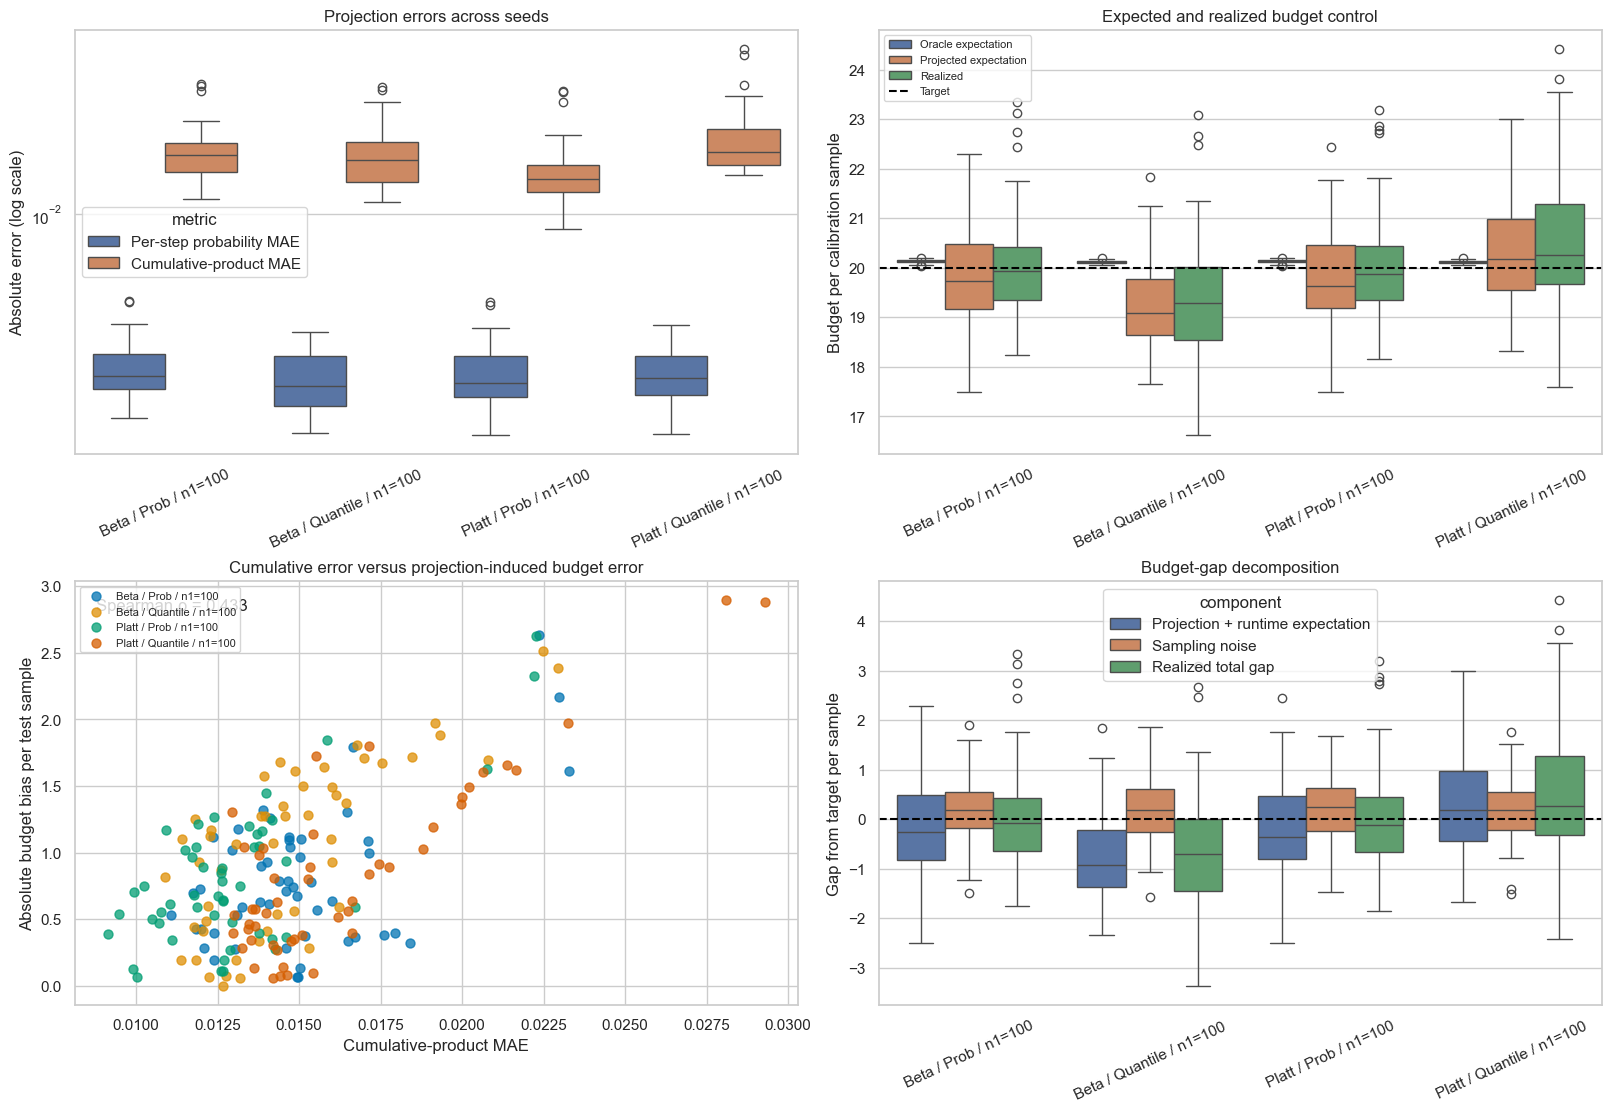

/Users/shai.feldman/Documents/Projects/dapro_rebuttal/notebooks/figures/dapro_projection/dapro_projection_dataset_toxicity_setup-cac326ec68_budget-20_cal-3000_tau-0.56_max-200/projection_accuracy_and_budget_control.png


In [7]:
sns.set_theme(style="whitegrid", context="notebook")
config_order = sorted(df["configuration"].unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)

error_long = df.melt(
    id_vars="configuration",
    value_vars=["projection_probability_mae", "projection_cumprod_mae"],
    var_name="metric",
    value_name="error",
)
error_long["metric"] = error_long["metric"].map({
    "projection_probability_mae": "Per-step probability MAE",
    "projection_cumprod_mae": "Cumulative-product MAE",
})
sns.boxplot(data=error_long, x="configuration", y="error", hue="metric", order=config_order, ax=axes[0, 0])
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Projection errors across seeds")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Absolute error (log scale)")
axes[0, 0].tick_params(axis="x", rotation=25)

budget_long = df.melt(
    id_vars="configuration",
    value_vars=[
        "oracle_expected_budget_per_sample",
        "projected_expected_budget_per_sample",
        "realized_budget_per_sample_evaluation",
    ],
    var_name="budget_kind",
    value_name="budget_per_sample",
)
budget_long["budget_kind"] = budget_long["budget_kind"].map({
    "oracle_expected_budget_per_sample": "Oracle expectation",
    "projected_expected_budget_per_sample": "Projected expectation",
    "realized_budget_per_sample_evaluation": "Realized",
})
sns.boxplot(data=budget_long, x="configuration", y="budget_per_sample", hue="budget_kind", order=config_order, ax=axes[0, 1])
axes[0, 1].axhline(BUDGET_PER_SAMPLE, color="black", linestyle="--", linewidth=1.5, label="Target")
axes[0, 1].set_title("Expected and realized budget control")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Budget per calibration sample")
axes[0, 1].tick_params(axis="x", rotation=25)
handles, labels = axes[0, 1].get_legend_handles_labels()
axes[0, 1].legend(handles, labels, fontsize=8)

palette = dict(zip(config_order, sns.color_palette("colorblind", len(config_order))))
for configuration, group in df.groupby("configuration"):
    axes[1, 0].scatter(
        group["projection_cumprod_mae"], group["abs_projection_budget_bias_per_test_sample"],
        alpha=0.75, s=42, label=configuration, color=palette[configuration],
    )
rank_corr = df[["projection_cumprod_mae", "abs_projection_budget_bias_per_test_sample"]].corr(method="spearman").iloc[0, 1]
axes[1, 0].text(0.03, 0.96, f"Spearman ρ = {rank_corr:.3f}", transform=axes[1, 0].transAxes, va="top")
axes[1, 0].set_title("Cumulative error versus projection-induced budget error")
axes[1, 0].set_xlabel("Cumulative-product MAE")
axes[1, 0].set_ylabel("Absolute budget bias per test sample")
axes[1, 0].legend(fontsize=8)

gap_long = df.melt(
    id_vars=["configuration", "calibration_sample_count"],
    value_vars=["projected_expected_budget_gap", "budget_sampling_gap", "realized_budget_gap"],
    var_name="component",
    value_name="total_gap",
)
gap_long["gap_per_sample"] = gap_long["total_gap"] / gap_long["calibration_sample_count"]
gap_long["component"] = gap_long["component"].map({
    "projected_expected_budget_gap": "Projection + runtime expectation",
    "budget_sampling_gap": "Sampling noise",
    "realized_budget_gap": "Realized total gap",
})
sns.boxplot(data=gap_long, x="configuration", y="gap_per_sample", hue="component", order=config_order, ax=axes[1, 1])
axes[1, 1].axhline(0, color="black", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Budget-gap decomposition")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Gap from target per sample")
axes[1, 1].tick_params(axis="x", rotation=25)

figure_path = figures_dir / "projection_accuracy_and_budget_control.png"
fig.savefig(figure_path, dpi=220, bbox_inches="tight")
plt.show()
print(figure_path)

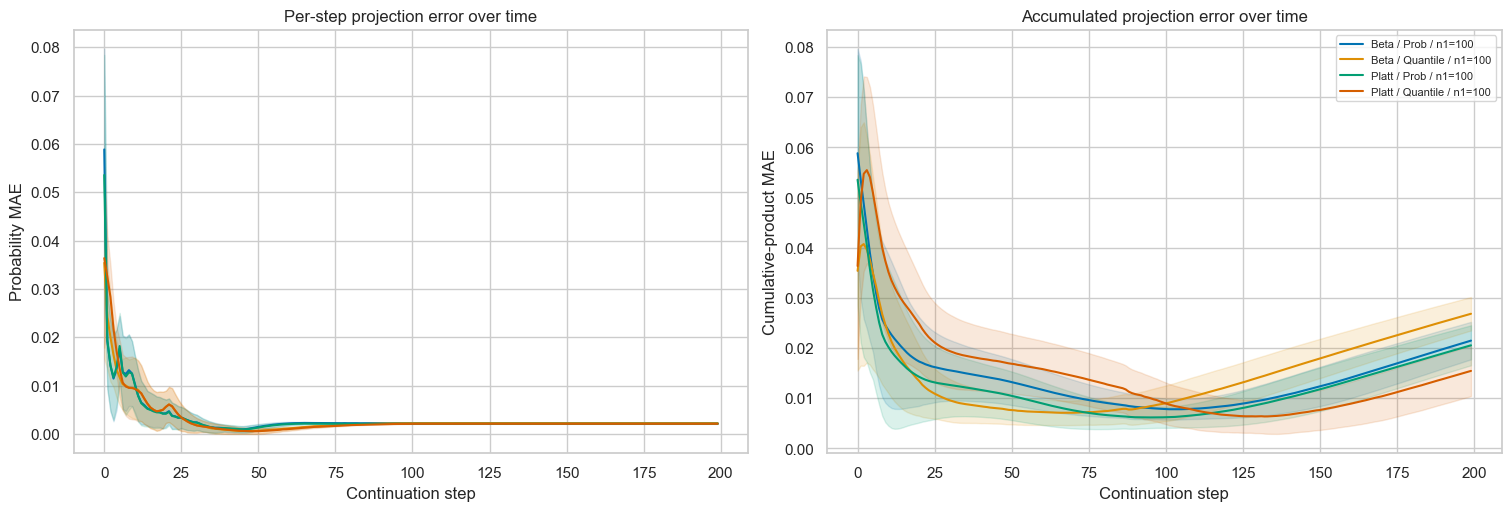

/Users/shai.feldman/Documents/Projects/dapro_rebuttal/notebooks/figures/dapro_projection/dapro_projection_dataset_toxicity_setup-cac326ec68_budget-20_cal-3000_tau-0.56_max-200/projection_error_over_time.png


In [8]:
time_records = []
for row in df.itertuples(index=False):
    probability_error = np.asarray(json.loads(row.projection_probability_mae_over_time), dtype=float)
    cumulative_error = np.asarray(json.loads(row.projection_cumprod_mae_over_time), dtype=float)
    active_count = np.asarray(json.loads(row.projection_active_count_over_time), dtype=int)
    for time_idx, (prob_error, cum_error, count) in enumerate(zip(probability_error, cumulative_error, active_count)):
        if count > 0 and np.isfinite(prob_error) and np.isfinite(cum_error):
            time_records.append({
                "configuration": row.configuration,
                "seed": row.seed,
                "time": time_idx,
                "probability_mae": prob_error,
                "cumprod_mae": cum_error,
                "active_count": count,
            })
time_df = pd.DataFrame(time_records)
time_summary = time_df.groupby(["configuration", "time"]).agg(
    probability_mean=("probability_mae", "mean"),
    probability_std=("probability_mae", "std"),
    cumprod_mean=("cumprod_mae", "mean"),
    cumprod_std=("cumprod_mae", "std"),
).reset_index().fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for configuration, group in time_summary.groupby("configuration"):
    color = palette[configuration]
    axes[0].plot(group["time"], group["probability_mean"], label=configuration, color=color)
    axes[0].fill_between(group["time"], np.maximum(0, group["probability_mean"] - group["probability_std"]), group["probability_mean"] + group["probability_std"], color=color, alpha=0.14)
    axes[1].plot(group["time"], group["cumprod_mean"], label=configuration, color=color)
    axes[1].fill_between(group["time"], np.maximum(0, group["cumprod_mean"] - group["cumprod_std"]), group["cumprod_mean"] + group["cumprod_std"], color=color, alpha=0.14)
axes[0].set(title="Per-step projection error over time", xlabel="Continuation step", ylabel="Probability MAE")
axes[1].set(title="Accumulated projection error over time", xlabel="Continuation step", ylabel="Cumulative-product MAE")
axes[1].legend(fontsize=8)
time_figure_path = figures_dir / "projection_error_over_time.png"
fig.savefig(time_figure_path, dpi=220, bbox_inches="tight")
plt.show()
print(time_figure_path)

In [15]:
import numpy as np

PROJECTION_FOR_TABLE = "platt"
SCORE_FOR_TABLE = "prob"
N1_FOR_TABLE = 100

required_table_columns = {
    "seed",
    "projection",
    "score",
    "n1",
    "projection_probability_mae",
    "projection_cumprod_mae",
}
missing = required_table_columns.difference(df.columns)
if missing:
    raise ValueError(
        "Missing columns required for the projection table: "
        f"{sorted(missing)}"
    )

table_df = df.loc[
    df["projection"].str.lower().eq(PROJECTION_FOR_TABLE)
    & df["score"].str.lower().eq(SCORE_FOR_TABLE)
    & df["n1"].astype(int).eq(N1_FOR_TABLE)
].copy()

if table_df.empty:
    raise ValueError(
        "No results found for "
        f"{PROJECTION_FOR_TABLE} / {SCORE_FOR_TABLE} / n1={N1_FOR_TABLE}."
    )

metric_specifications = [
    ("projection_probability_mae", "Per-step MAE", 4),
    ("projection_cumprod_mae", "Cumprod MAE", 4),
]

headers = [label for _, label, _ in metric_specifications]
values = []

for column, _, digits in metric_specifications:
    mean = table_df[column].mean()
    std = table_df[column].std(ddof=1)
    if not np.isfinite(std):
        std = 0.0
    values.append(f"{mean:.{digits}f} +/- {std:.{digits}f}")

lines = [
    "| " + " | ".join(headers) + " |",
    "| " + " | ".join(["---"] * len(headers)) + " |",
    "| " + " | ".join(values) + " |",
    "",
    (
        f"Results use Platt scaling with the probability score and "
        f"N1={N1_FOR_TABLE}. Entries are mean +/- standard deviation over "
        f"{table_df['seed'].nunique()} random splits. Cumprod MAE measures "
        "the error in the cumulative continuation-probability product."
    ),
]

projection_accuracy_markdown = "\n".join(lines)

expected_pipe_count = len(headers) + 1
for line in lines[:3]:
    if line.count("|") != expected_pipe_count:
        raise RuntimeError(f"Invalid Markdown table row: {line}")

print(projection_accuracy_markdown)

| Per-step MAE | Cumprod MAE |
| --- | --- |
| 0.0036 +/- 0.0007 | 0.0130 +/- 0.0027 |

Results use Platt scaling with the probability score and N1=100. Entries are mean +/- standard deviation over 50 random splits. Cumprod MAE measures the error in the cumulative continuation-probability product.
